# Supplementary Figure S1: Data Quality Control
Quality control metrics for the whole-body mouse spatial transcriptomics dataset (GSE248904).

In [1]:
%matplotlib inline
import omicverse as ov
ov.style(font_path='Arial')

🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import os

LEGEND_FS = 11; TICK_FS = 12; LABEL_FS = 13; TITLE_FS = 13; TEXT_FS = 12

def save_all_formats(fig, basepath, dpi=300):
    fig.savefig(f"{basepath}.pdf", bbox_inches="tight", dpi=dpi)
    fig.savefig(f"{basepath}.png", bbox_inches="tight", dpi=dpi)
    fig.savefig(f"{basepath}.svg", bbox_inches="tight")

BASE = '../analysis/26_gsmap'
os.makedirs(f'{BASE}/figures', exist_ok=True)

## Load whole-body data (obs only for QC metrics)

In [3]:
# Load full h5ad obs only (memory efficient)
adata = ad.read_h5ad(f'{BASE}/data/st/GSE248904_All_Samples.h5ad', backed='r')
obs = adata.obs.copy()
# Filter to CTRL samples only
obs_ctrl = obs[obs['Sample'].isin(['CTRL_1', 'CTRL_2'])].copy()
obs_ctrl['Organ_Full_Name'] = obs_ctrl['Organ_Full_Name'].astype(str)
# Exclude 'Other' organ
obs_ctrl = obs_ctrl[obs_ctrl['Organ_Full_Name'] != 'Other'].copy()
print(f'Total CTRL spots: {len(obs_ctrl)}')
print(f'Organs: {obs_ctrl["Organ_Full_Name"].nunique()}')

Total CTRL spots: 1120354
Organs: 16


## Panel A: Violin plots of QC metrics per organ

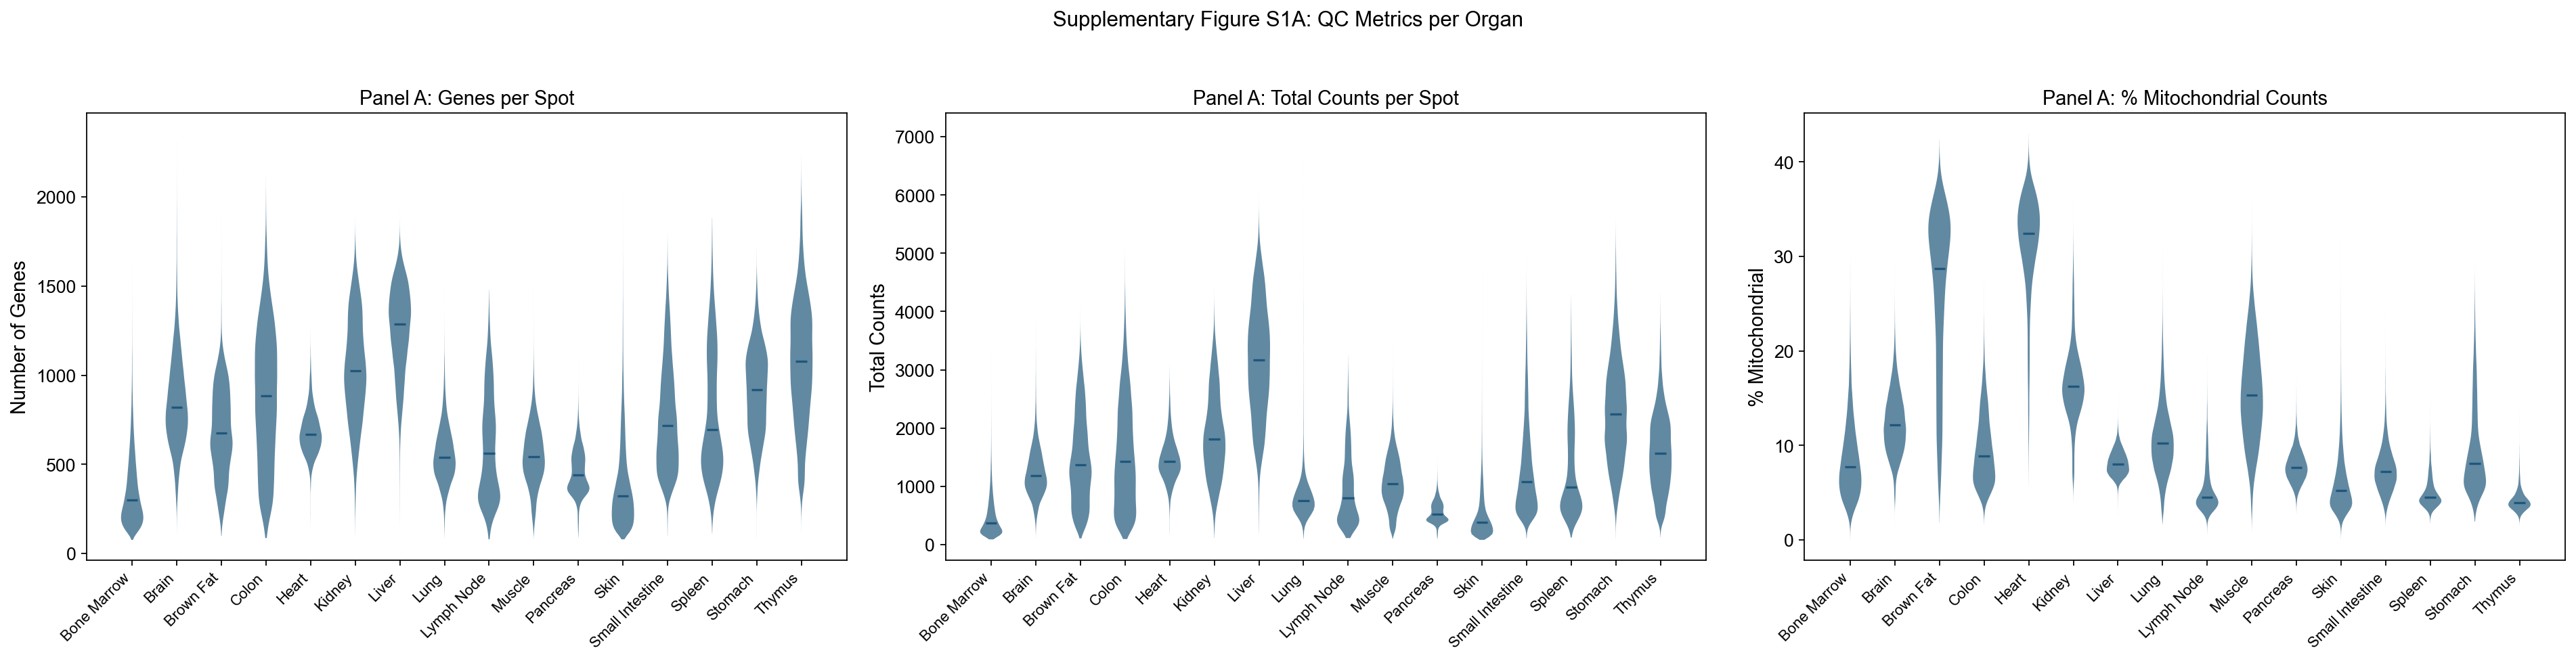

In [4]:
organ_order = sorted(obs_ctrl['Organ_Full_Name'].unique())

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

metrics = [
    ('n_genes_by_counts', 'Number of Genes', 'Panel A: Genes per Spot'),
    ('total_counts', 'Total Counts', 'Panel A: Total Counts per Spot'),
    ('pct_counts_mt', '% Mitochondrial', 'Panel A: % Mitochondrial Counts'),
]

for ax, (col, ylabel, title) in zip(axes, metrics):
    data = [obs_ctrl.loc[obs_ctrl['Organ_Full_Name'] == org, col].dropna().values for org in organ_order]
    parts = ax.violinplot(data, showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_alpha(0.7)
    ax.set_xticks(range(1, len(organ_order) + 1))
    ax.set_xticklabels(organ_order, rotation=45, ha='right', fontsize=TICK_FS - 2)
    ax.set_ylabel(ylabel, fontsize=LABEL_FS)
    ax.set_title(title, fontsize=TITLE_FS)
    ax.tick_params(axis='y', labelsize=TICK_FS)

fig.suptitle('Supplementary Figure S1A: QC Metrics per Organ', fontsize=TITLE_FS + 1, y=1.02)
fig.tight_layout()
save_all_formats(fig, f'{BASE}/figures/S01A_qc_violins')

## Panel B: Spatial map of pct_counts_mt for CTRL_1

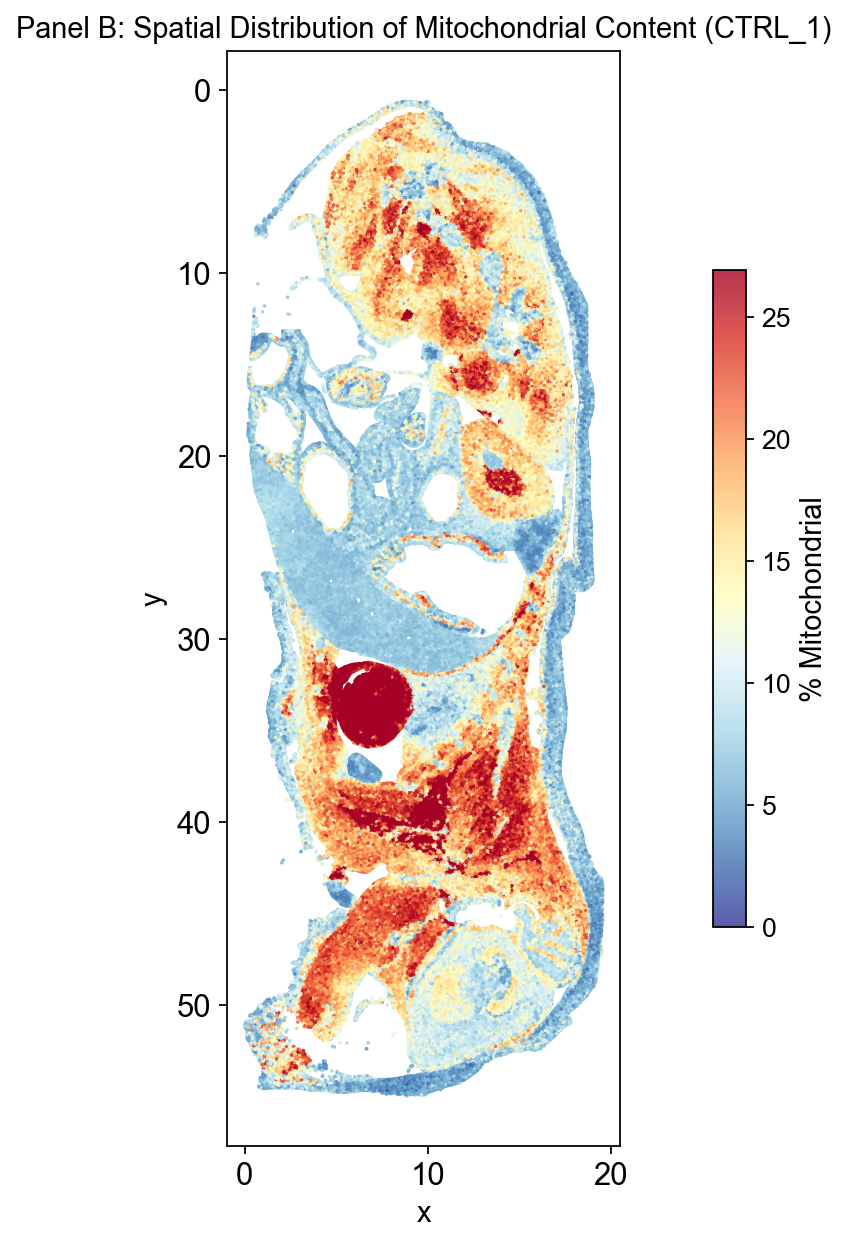

In [5]:
obs_ctrl1 = obs_ctrl[obs_ctrl['Sample'] == 'CTRL_1'].copy()

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
sc = ax.scatter(
    obs_ctrl1['x_plotting'], obs_ctrl1['y_plotting'],
    c=obs_ctrl1['pct_counts_mt'], cmap='RdYlBu_r', s=0.3, alpha=0.8,
    vmin=0, vmax=obs_ctrl1['pct_counts_mt'].quantile(0.95),
    rasterized=True
)
cbar = fig.colorbar(sc, ax=ax, shrink=0.6, label='% Mitochondrial')
cbar.ax.tick_params(labelsize=TICK_FS)
cbar.set_label('% Mitochondrial', fontsize=LABEL_FS)
ax.set_title('Panel B: Spatial Distribution of Mitochondrial Content (CTRL_1)', fontsize=TITLE_FS)
ax.set_xlabel('x', fontsize=LABEL_FS)
ax.set_ylabel('y', fontsize=LABEL_FS)
ax.set_aspect('equal')
ax.invert_yaxis()
fig.tight_layout()
save_all_formats(fig, f'{BASE}/figures/S01B_spatial_mt')

## Panel C: Replicate consistency (CTRL_1 vs CTRL_2 median gene counts per organ)

Organs with both replicates: 16
Sample           CTRL_1  CTRL_2
Organ_Full_Name                
Bone Marrow       367.0   275.0
Brain             933.0   752.0
Brown Fat         594.0   782.0
Colon            1051.0   755.0
Heart             638.0   763.0


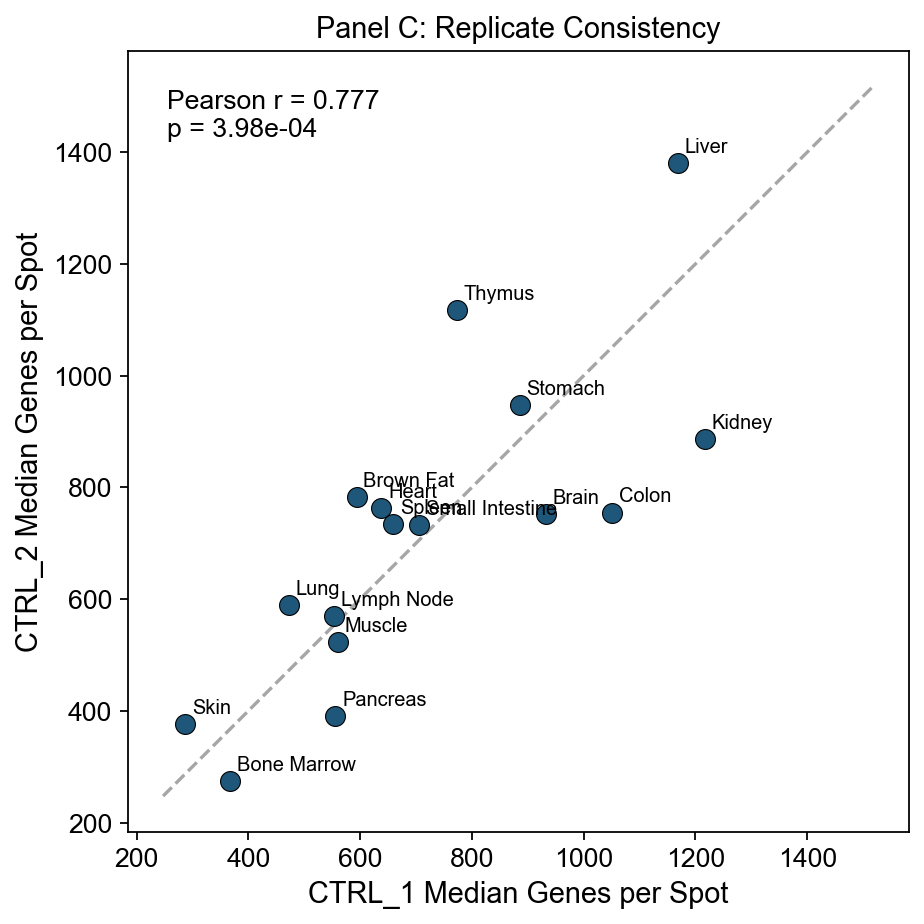

In [6]:
median_genes = obs_ctrl.groupby(['Organ_Full_Name', 'Sample'], observed=True)['n_genes_by_counts'].median().unstack()
median_genes = median_genes.dropna()
print(f"Organs with both replicates: {len(median_genes)}")
print(median_genes.head())

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(median_genes['CTRL_1'], median_genes['CTRL_2'], s=80, zorder=3, edgecolors='k', linewidths=0.5)
for organ in median_genes.index:
    ax.annotate(organ, (median_genes.loc[organ, 'CTRL_1'], median_genes.loc[organ, 'CTRL_2']),
               fontsize=LEGEND_FS - 2, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')

# Diagonal line
lims = [median_genes.min().min() * 0.9, median_genes.max().max() * 1.1]
ax.plot(lims, lims, '--', color='grey', alpha=0.7, zorder=1)

from scipy.stats import pearsonr
r, pval = pearsonr(median_genes['CTRL_1'], median_genes['CTRL_2'])
ax.text(0.05, 0.95, f'Pearson r = {r:.3f}\np = {pval:.2e}', transform=ax.transAxes,
        fontsize=TEXT_FS, va='top', ha='left')

ax.set_xlabel('CTRL_1 Median Genes per Spot', fontsize=LABEL_FS)
ax.set_ylabel('CTRL_2 Median Genes per Spot', fontsize=LABEL_FS)
ax.set_title('Panel C: Replicate Consistency', fontsize=TITLE_FS)
ax.tick_params(labelsize=TICK_FS)
fig.tight_layout()
save_all_formats(fig, f'{BASE}/figures/S01C_replicate_consistency')

## Panel D: Homolog mapping coverage

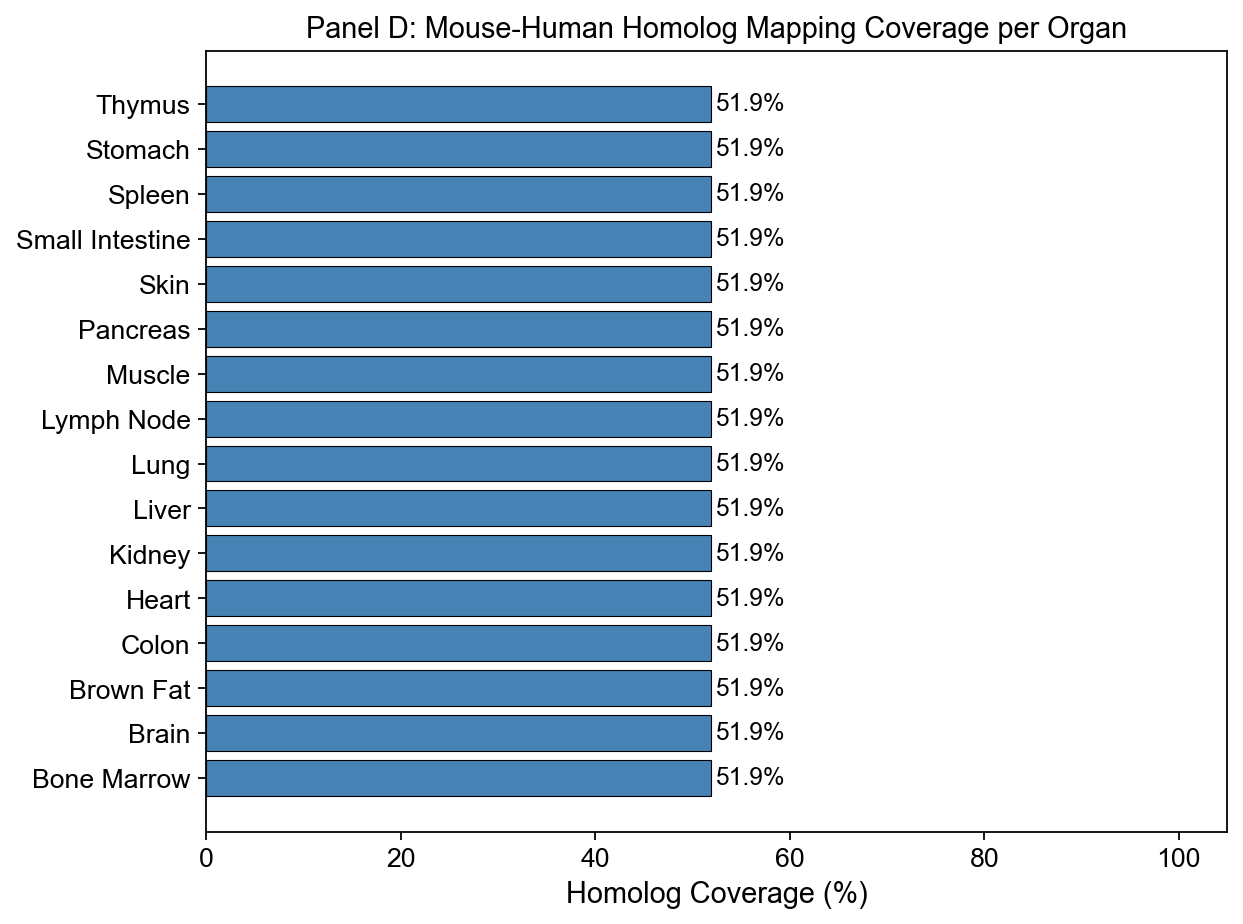

In [7]:
# Load homolog mapping
homologs = pd.read_csv(f'{BASE}/data/gsMap_resource/homologs/mouse_human_homologs.txt', sep='\t')
human_genes_in_map = set(homologs['HUMAN_GENE_SYM'].dropna().unique())
mouse_genes_in_map = set(homologs['MOUSE_GENE_SYM'].dropna().unique())

# Load gene names from one per-organ h5ad
organs_files = sorted([f for f in os.listdir(f'{BASE}/data/st/per_organ/') if f.endswith('.h5ad') and 'CTRL1' in f])
coverage_data = []
for fname in organs_files:
    organ_name = fname.replace('_CTRL1.h5ad', '').replace('_', ' ')
    tmp = ad.read_h5ad(f'{BASE}/data/st/per_organ/{fname}', backed='r')
    gene_names = set(tmp.var_names.tolist())
    mapped = gene_names & mouse_genes_in_map
    coverage_data.append({
        'Organ': organ_name,
        'Total Genes': len(gene_names),
        'Mapped Genes': len(mapped),
        'Coverage (%)': 100.0 * len(mapped) / len(gene_names) if len(gene_names) > 0 else 0
    })
    del tmp

cov_df = pd.DataFrame(coverage_data).sort_values('Coverage (%)', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(cov_df['Organ'], cov_df['Coverage (%)'], color='steelblue', edgecolor='k', linewidth=0.5)
for bar, val in zip(bars, cov_df['Coverage (%)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=TEXT_FS - 1)
ax.set_xlabel('Homolog Coverage (%)', fontsize=LABEL_FS)
ax.set_title('Panel D: Mouse-Human Homolog Mapping Coverage per Organ', fontsize=TITLE_FS)
ax.tick_params(labelsize=TICK_FS)
ax.set_xlim(0, 105)
fig.tight_layout()
save_all_formats(fig, f'{BASE}/figures/S01D_homolog_coverage')